In [759]:
%matplotlib notebook

In [760]:
import pandas as pd
import re
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from typing import Tuple, List
import numpy as np

In [761]:
ms2pip_preds = pickle.load(
    open("/home/robbe/MuMDIA/results/config_playing/ms2pip_predictions.pkl", "rb")
)
deeplc_preds = pickle.load(
    open("/home/robbe/MuMDIA/results/config_playing/predictions_deeplc.pkl", "rb")
)
df_psms = pd.read_csv("/home/robbe/MuMDIA/results/config_playing/df_psms.tsv", sep="\t")
df_psms["precursor"] = df_psms["peptide"] + "/" + df_psms["charge"].astype(str)
df_fragment = pd.read_csv(
    "/home/robbe/MuMDIA/results/config_playing/df_fragment.tsv", sep="\t"
)
df_fragment["fragment_names"] = df_fragment["fragment_type"].astype(str) + df_fragment[
    "fragment_ordinals"
].astype("Int64").astype(str)

In [762]:
ms2dict = pickle.load(open("/home/robbe/MuMDIA/debug/ms2dict.pkl", "rb"))
ms1_dict = pickle.load(open("/home/robbe/MuMDIA/debug/ms1_dict.pkl", "rb"))
ms2_to_ms1_dict = pickle.load(
    open("/home/robbe/MuMDIA/debug/ms2_to_ms1_dict.pkl", "rb")
)

In [763]:
deeplc_preds = deeplc_preds.to_pandas()

# 0. Helpers

In [764]:
def plot_XIC(fragments: pd.DataFrame, show: bool = False):
    """
    Plot fragment Extracted Ion Chromatograms (XICs) with PSM markers.

    Parameters
    ----------
    fragments : pd.DataFrame
        Must contain columns:
        ['fragment_type', 'fragment_ordinals', 'rt', 'fragment_intensity', 'psm_id'].
    show : bool, optional
        If True, call plt.show() before returning (useful in scripts).

    Returns
    -------
    fig : matplotlib.figure.Figure
    ax  : matplotlib.axes.Axes
    """
    required = {
        "fragment_type",
        "fragment_ordinals",
        "rt",
        "fragment_intensity",
        "psm_id",
    }
    missing = required.difference(fragments.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    # Defensive copy and typing
    df = fragments.copy()

    # Coerce numeric fields and drop unplottable rows
    df["rt"] = pd.to_numeric(df["rt"], errors="coerce")
    df["fragment_intensity"] = pd.to_numeric(df["fragment_intensity"], errors="coerce")
    df = df.dropna(subset=["rt", "fragment_intensity"])

    if df.empty:
        raise ValueError(
            "After coercion and NaN removal, there is no data to plot. "
            "Check that 'rt' and 'fragment_intensity' are numeric."
        )

    fragment_names = df["fragment_names"].unique()
    if len(fragment_names) == 0:
        raise ValueError("No fragment names could be derived from the input.")

    # Colors and markers
    cmap = plt.cm.get_cmap("tab20", len(fragment_names))
    fragment_color_map = {frag: cmap(i) for i, frag in enumerate(fragment_names)}
    marker_styles = ["o", "s", "D", "^", "v", "p", "*", "X", "H", "<", ">"]

    psm_ids = df["psm_id"].unique()
    psm_marker_map = {
        psm: marker_styles[i % len(marker_styles)] for i, psm in enumerate(psm_ids)
    }

    fig, ax = plt.subplots(figsize=(12, 6))

    # Lines per fragment
    plotted_any = False
    for frag in fragment_names:
        frag_df = df.loc[df["fragment_names"] == frag].sort_values("rt")
        if frag_df.empty:
            continue
        ax.plot(
            frag_df["rt"].to_numpy(),
            frag_df["fragment_intensity"].to_numpy(),
            color=fragment_color_map[frag],
            linestyle="-",
            linewidth=1,
            label=str(frag),
        )
        plotted_any = True

    # Marker overlays per PSM within each fragment
    for frag in fragment_names:
        frag_df = df.loc[df["fragment_names"] == frag]
        if frag_df.empty:
            continue
        for psm in psm_ids:
            psm_df = frag_df.loc[frag_df["psm_id"] == psm]
            if psm_df.empty:
                continue
            ax.scatter(
                psm_df["rt"].to_numpy(),
                psm_df["fragment_intensity"].to_numpy(),
                color=fragment_color_map[frag],
                marker=psm_marker_map[psm],
                edgecolor="k",
                linewidths=0.5,
                s=24,
            )

    if not plotted_any:
        raise ValueError(
            "No non-empty fragment groups to plot. "
            "Verify 'fragment_type'/'fragment_ordinals' values."
        )

    ax.set_xlabel("Retention Time (RT)")
    ax.set_ylabel("Fragment Intensity")

    # Fragment legend
    frag_legend_elements = [
        Line2D([0], [0], color=fragment_color_map[frag], lw=2, label=str(frag))
        for frag in fragment_names
    ]
    legend1 = ax.legend(
        handles=frag_legend_elements,
        title="Fragment",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=True,
    )
    ax.add_artist(legend1)

    fig.tight_layout()

    if show:
        plt.show()

    return fig

In [765]:
def find_top_n_fragments(fragments: pd.DataFrame, top_n: int = 6) -> List[str]:
    """
    Find the top n fragments by their maximum intensity.
    """
    top_fragments = (
        (
            fragments.groupby("fragment_names")["fragment_intensity"]
            .max()
            .nlargest(top_n)
        )
        .reset_index()["fragment_names"]
        .tolist()
    )
    return top_fragments

In [766]:
def find_best_fragment(
    fragments: pd.DataFrame, top_n: int = 6
) -> Tuple[str, List[str]]:
    """
    Identify the "best" fragment. This fragment is defined as the fragment from the top 6 most intense fragments that maximizes the sum of Pearson correlations with the remaining 5 out of the top 6 list
    """
    # Compute the top 6 most intense fragments in a list
    top_fragments = find_top_n_fragments(fragments, top_n)

    # Filter the original fragments to keep only the top fragments
    filtered_fragments = fragments[fragments["fragment_names"].isin(top_fragments)]

    # Compute pairwise Pearson correlations
    corr_matrix = filtered_fragments.pivot_table(
        index="rt", columns="fragment_names", values="fragment_intensity"
    ).corr(method="pearson")

    # Find the fragment with the highest sum of correlations
    if corr_matrix.empty:
        return None
    # corr_matrix.set_index("fragment_names", inplace=True)
    corr_matrix["fragment_corr_sum"] = corr_matrix.sum(axis=1)
    best_fragment = corr_matrix["fragment_corr_sum"].idxmax()
    return best_fragment

In [ ]:
def search_sorted_tolerance_np(
    arr, target, tol=6.5
):  # TODO: propagate config fragment mass tolerance
    arr = np.asarray(arr)
    # Check if array is sorted, and if not, sort
    if not np.all(np.diff(arr) >= 0):
        arr = np.sort(arr)
    idx = np.searchsorted(arr, target)
    candidates = []
    if 0 <= idx < len(arr):
        candidates.append((idx, arr[idx]))
    if 0 <= idx - 1 < len(arr):
        candidates.append((idx - 1, arr[idx - 1]))
    if not candidates:
        return None, None
    best_idx, best_val = min(candidates, key=lambda x: abs(x[1] - target))
    return (best_idx, best_val) if abs(best_val - target) <= tol else (None, None)

In [768]:
def find_intensity_ms2dict(
    row, ms2dict, offset=1, scan_prefix="controllerType=0 controllerNumber=1 scan="
):
    scan = row["scan"]
    scan_offset = scan + offset
    ms2dict_scan = ms2dict.get(f"{scan_prefix}{scan_offset}", {})
    fragment_mz = row["fragment_mz_experimental"]
    # Find index of fragment_mz in ms2dict_scan.mz
    mzs = ms2dict_scan.get("mz", [])
    intensities = ms2dict_scan.get("intensity", [])
    best_idx, best_val = search_sorted_tolerance_np(mzs, fragment_mz)
    return intensities[best_idx] if best_idx is not None else None

In [769]:
def smooth_trace(
    fragments: pd.DataFrame, mode="sg", window_length=3, polyorder=1, ms2dict=None
):
    """Smooth the fragment intensity traces using a specified smoothing method."""
    if mode == "sg":
        # Apply Savitzky-Golay smoothing per fragment trace using scipy.signal.savgol_filter
        smoothed = []
        for frag, frag_df in fragments.groupby("fragment_names"):
            frag_df_sorted = frag_df.sort_values("rt")
            intensity = frag_df_sorted["fragment_intensity"].to_numpy()
            wl = min(window_length, len(intensity))
            if wl % 2 == 0:
                wl += 1
            if wl > len(intensity):
                wl = len(intensity) if len(intensity) % 2 == 1 else len(intensity) - 1
            if wl < 3:
                wl = 3
            if len(intensity) < wl:
                smoothed_intensity = intensity
            else:
                smoothed_intensity = savgol_filter(
                    intensity, window_length=wl, polyorder=polyorder
                )
            frag_df_sorted = frag_df_sorted.copy()
            frag_df_sorted["fragment_intensity"] = smoothed_intensity
            smoothed.append(frag_df_sorted)
        return pd.concat(smoothed, ignore_index=True)
    if mode == "min_neighbor_rt":
        # Apply int(RT) = min(int(prev_RT_point), int(RT), int(next_RT_point))
        smoothed = []
        for frag, frag_df in fragments.groupby("fragment_names"):
            frag_df_sorted = frag_df.sort_values("rt").reset_index(drop=True)
            intensity = frag_df_sorted["fragment_intensity"].to_numpy()
            smoothed_intensity = intensity.copy()
            for i in range(1, len(intensity) - 1):
                smoothed_intensity[i] = min(
                    intensity[i - 1], intensity[i], intensity[i + 1]
                )
            frag_df_sorted = frag_df_sorted.copy()
            frag_df_sorted["fragment_intensity"] = smoothed_intensity
            smoothed.append(frag_df_sorted)
        return pd.concat(smoothed, ignore_index=True)

    if mode == "min_neighbor_scan":
        # Apply int(scan) = min(int(prev_scan), int(scan), int(next_scan))
        # TODO: make work with other scannr formats
        fragments["scan"] = fragments["scannr"].apply(
            lambda x: int(re.search(r"scan=(\d+)", x).group(1))
        )
        fragments["intensity_prev_scan"] = fragments.apply(
            lambda row: find_intensity_ms2dict(row, ms2dict, offset=-1), axis=1
        )
        fragments["intensity_next_scan"] = fragments.apply(
            lambda row: find_intensity_ms2dict(row, ms2dict, offset=1), axis=1
        )

        smoothed_fragments = fragments.copy()
        smoothed_fragments["fragment_intensity"] = smoothed_fragments[
            ["intensity_prev_scan", "fragment_intensity", "intensity_next_scan"]
        ].min(axis=1)

        return smoothed_fragments

    else:
        raise ValueError(
            f"Unknown smoothing mode: {mode}"
        )  # TODO: Implement other smoothing modes

In [779]:
precursor = df_psms[df_psms["precursor"] == "GYINSLGALTGGQALQQAK/2"]

In [780]:
precursor_fragments = df_fragment[df_fragment["psm_id"].isin(precursor["psm_id"])]

In [781]:
precursor_fragments["ppm_error"] = (
    abs(
        precursor_fragments["fragment_mz_calculated"]
        - precursor_fragments["fragment_mz_experimental"]
    )
    / precursor_fragments["fragment_mz_calculated"]
    * 1e6
)

In [783]:
smoothed = smooth_trace(precursor_fragments, mode="sg")

<IPython.core.display.Javascript object>

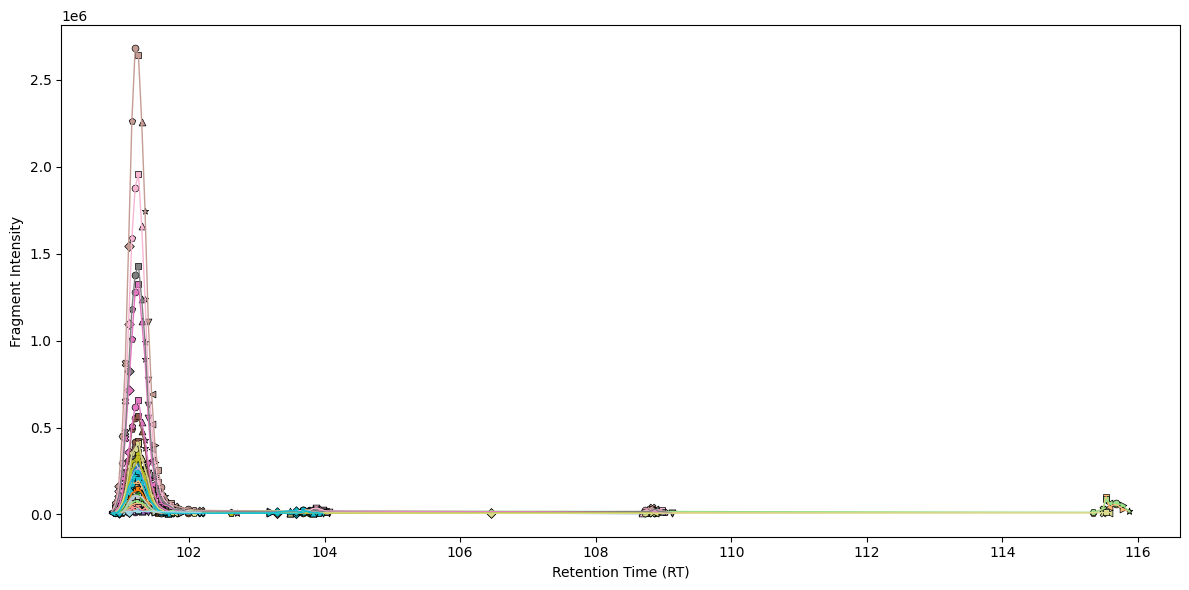

In [784]:
fig = plot_XIC(precursor_fragments)
fig

# 1. Features of Ion coelution (MS2 level)

## 1.1 Pearson correlations of top 12 fragments’ elution profiles (fragments ordered by their reference library intensities) with the smoothed elution profile of the “best” fragment (12 scores)


In [785]:
def pearson_corr_top_n(
    fragments, n=12, ms2_acc=13, ms2_acc_factor=None, reverse=False, use_all_rt=False
) -> Tuple[np.ndarray, pd.Series, np.ndarray]:
    """
    Compute Pearson correlations of all fragments' elution profiles
    with the smoothed elution profile of the "best" fragment,
    then filter to the top n fragments by intensity.

    Parameters
    ----------
    fragments : pd.DataFrame
        Fragment data containing RT and intensity information
    n : int, default=12
        Number of top fragments to consider
    ms2_acc : float, default=13
        Base mass accuracy
    ms2_acc_factor : float, optional
        Factor to multiply ms2_acc for filtering
    reverse : bool, default=False
        If True, return correlations for fragments NOT in top n
    use_all_rt : bool, default=False
        If True, use all RT time points from all fragments (filling missing with 0)
        If False, use only overlapping RT time points between fragments

    Returns
    -------
    sorted_correlations : np.ndarray
        Correlation coefficients for selected fragments
    best_trace : pd.Series
        Raw elution profile of best fragment
    smoothed_best_trace : np.ndarray
        Smoothed elution profile of best fragment
    correlations : dict
        All fragment correlations
    """
    # Optionally filter by ppm_error
    if ms2_acc_factor is not None:
        fragments = fragments[fragments["ppm_error"] <= ms2_acc * ms2_acc_factor]

    best_fragment = find_best_fragment(fragments)
    if best_fragment is None:
        raise ValueError("Could not identify the best fragment.")

    # Pivot to create a matrix of rt vs fragment intensity for all fragments
    pivot_table = fragments.pivot_table(
        index="rt", columns="fragment_names", values="fragment_intensity"
    )

    # Smooth the best fragment's trace
    if best_fragment not in pivot_table.columns:
        raise ValueError(f"Best fragment '{best_fragment}' not found in data.")
    best_trace = pivot_table[best_fragment].dropna()
    smoothed_best_trace = savgol_filter(
        best_trace,
        window_length=3,
        polyorder=1,
    )

    # Compute Pearson correlations for all fragments
    correlations = {}

    if use_all_rt:
        # Use all RT time points from all fragments, fill missing with 0
        # Get union of all RT time points
        all_rt_points = pivot_table.index

        # Fill missing values with 0 for all fragments
        pivot_filled = pivot_table.fillna(0.0)

        # Get smoothed best trace aligned to all RT points
        best_trace_aligned = pivot_filled[best_fragment]
        smoothed_best_aligned = savgol_filter(
            best_trace_aligned,
            window_length=min(3, len(best_trace_aligned)),
            polyorder=1,
        )

        for frag in pivot_table.columns:
            frag_trace_aligned = pivot_filled[frag]

            # Calculate correlation using all time points
            if len(frag_trace_aligned) < 2:
                correlations[frag] = float("nan")
                continue

            corr = pd.Series(smoothed_best_aligned, index=all_rt_points).corr(
                frag_trace_aligned
            )
            correlations[frag] = corr
    else:
        # Original logic: use only overlapping RT time points
        for frag in pivot_table.columns:
            frag_trace = pivot_table[frag].dropna()
            common_index = best_trace.index.intersection(frag_trace.index)
            if len(common_index) < 2:
                correlations[frag] = float("nan")
                continue
            corr = (
                pd.Series(smoothed_best_trace, index=best_trace.index)
                .loc[common_index]
                .corr(frag_trace.loc[common_index])
            )
            correlations[frag] = corr

    # Find top n fragments by intensity
    top_fragments = find_top_n_fragments(fragments, n)
    if not reverse:
        sorted_correlations = np.array(
            [correlations[frag] for frag in top_fragments if frag in correlations]
        )
    else:
        sorted_correlations = np.array(
            [correlations[frag] for frag in correlations if frag not in top_fragments]
        )

    return sorted_correlations, best_trace, smoothed_best_trace, correlations

In [787]:
sorted_correlations, best_trace, smoothed_best_trace, correlations = pearson_corr_top_n(
    precursor_fragments, n=12
)
sorted_correlations

array([0.99792412, 0.99782506, 0.99902171, 0.99781988, 0.99792208,
       0.99718701, 0.99441233, 0.99653843, 0.99712779, 0.99110063,
       0.99506514, 0.99443747])

## 1.2 Sum of these correlations for the top 6 fragments; calculated for chromatograms extracted at the base mass accuracy as well as 0.45 and 0.2 of the base mass accuracy (3 scores)

In [788]:
def sum_corrs_topn_mass_accs(
    fragments, n=6, ms2_acc=13, ms2_acc_factors=[1, 0.45, 0.2], use_all_rt=False
):
    """
    Compute the sum of Pearson correlations for the top n fragments
    across different mass accuracy factors.
    """
    results = np.array([])
    for factor in ms2_acc_factors:
        corrs, _, _, _ = pearson_corr_top_n(
            fragments,
            n=n,
            ms2_acc=ms2_acc,
            ms2_acc_factor=factor,
            use_all_rt=use_all_rt,
        )
        results = np.append(results, corrs.sum())
    return results

In [789]:
sum_corrs_topn_mass_accs(precursor_fragments)

array([5.98771326, 5.98526176, 5.98627818])

## 1.3 Sum of correlations for the remaining fragments, without normalisation and with normalisation by number of remaining fragments (2 scores)

In [790]:
def lower_frag_corrs_sum(fragments, ignore_top_n=12, use_all_rt=False):
    sorted_correlations, _, _, _ = pearson_corr_top_n(
        fragments, n=ignore_top_n, reverse=True, use_all_rt=use_all_rt
    )

    # Remove NaNs before summing
    valid_corrs = sorted_correlations[~np.isnan(sorted_correlations)]
    non_normalised = np.sum(valid_corrs)
    normalised = non_normalised / len(valid_corrs) if len(valid_corrs) > 0 else 0
    result = np.array([non_normalised, normalised])
    return result

In [791]:
result = lower_frag_corrs_sum(precursor_fragments)
result

array([17.40960673,  0.91629509])

## 1.4 Sum of these correlations for the 3 b fragments (charge 1) with highest correlations (1 score)

In [ ]:
def best_b_corr_sum(fragments, n=3, use_all_rt=True):
    _, _, _, correlations = pearson_corr_top_n(fragments, use_all_rt=use_all_rt)
    b_fragments = [frag for frag, corr in correlations.items() if frag.startswith("b")]
    # Sort by correlation and take top n
    b_fragments = sorted(b_fragments, key=lambda x: correlations[x], reverse=True)[:n]
    corrs = [correlations[frag] for frag in b_fragments]
    return sum(corrs)

In [793]:
best_b_corr_sum(precursor_fragments)

np.float64(2.981040132933891)

## 1.5 Sum of such correlations for the top 6 fragments with elution profiles x() first processed using the x(scan) -> min(x(scan - 1), x(scan), x(scan + 1)) replacement

In [794]:
def top_n_corrs_sum_processed_profile(
    fragments, n=6, use_all_rt=False, smooth_mode="min_neighbor_scan", ms2dict=None
):
    if smooth_mode == "min_neighbor_rt":
        smoothed_fragments = smooth_trace(fragments, mode=smooth_mode)
    if smooth_mode == "min_neighbor_scan":
        smoothed_fragments = smooth_trace(fragments, mode=smooth_mode, ms2dict=ms2dict)
    sorted_correlations, _, _, _ = pearson_corr_top_n(
        smoothed_fragments, n=n, use_all_rt=use_all_rt
    )
    sum_processed_profile = np.sum(sorted_correlations)
    return sum_processed_profile

In [795]:
top_n_corrs_sum_processed_profile(precursor_fragments, ms2dict=ms2dict)

np.float64(3.9526830186876674)

## 1.6 Correlation between the elution profile at the m/z value that corresponds to the non-fragmented precursor and the smoothed elution profile of the “best” fragment

### TO DISCUSS: is this tolerance RT matching okay? 

In [796]:
def build_elution_profile(
    precursor_mz,
    ms1_dict,
    tol=50,
    tol_unit="ppm",
    wide_window=False,
    in_sec=True,
    acc_factor=1.0,
):
    # Gather all MS1 features within the specified tolerance
    elution_profile = {}
    if not wide_window:
        if tol_unit == "ppm":
            tol_mz = precursor_mz * tol / 1e6
        else:
            tol_mz = tol
    else:
        # TODO: implement wide window. How does it work?
        pass

    tol_mz *= acc_factor

    for scan, scan_dict in ms1_dict.items():
        mzs = scan_dict.get("mz", [])
        intensities = scan_dict.get("intensity", [])
        rt = scan_dict.get("retention_time", [])
        if in_sec:
            rt = rt / 60

        best_idx, best_val = search_sorted_tolerance_np(mzs, precursor_mz, tol=tol_mz)

        # candidates is a list of tuples (idx, mz).
        # elution_profile should be a dictionary of "rt":"intensity"
        if best_idx is not None:
            elution_profile[rt] = intensities[best_idx]

    return elution_profile

In [ ]:
def corr_precursor_best_fragment(
    precursor, precursor_fragments, ms1_dict, acc_factor=1.0, rt_tolerance=5.0
):
    precursor_mz = precursor["calcmass"].iloc[0] / precursor["charge"].iloc[0]
    elution_profile = build_elution_profile(
        precursor_mz, ms1_dict, acc_factor=acc_factor
    )

    _, best_trace, smoothed_best_trace, _ = pearson_corr_top_n(precursor_fragments)
    # Combine retention times and smoothed intensities into a DataFrame
    smoothed_best_df = pd.DataFrame(
        {"rt": best_trace.index, "smoothed_intensity": smoothed_best_trace}
    )
    # align rt for smoothed_best_df and elution_profile
    # Convert elution_profile dict to DataFrame for alignment
    elution_df = pd.DataFrame(
        list(elution_profile.items()), columns=["rt", "intensity"]
    )

    # Merge on 'rt' using nearest RT within a small tolerance
    merged = pd.merge_asof(
        smoothed_best_df.sort_values("rt"),
        elution_df.sort_values("rt"),
        on="rt",
        direction="nearest",
        tolerance=rt_tolerance,  # TODO: How to set this based on Sage config?
    )

    # Calculate pearson correlation
    corr = merged["smoothed_intensity"].corr(merged["intensity"])
    return corr, merged

In [798]:
corr, merged = corr_precursor_best_fragment(precursor, precursor_fragments, ms1_dict)
corr

np.float64(0.47362079830883386)

In [799]:
merged

,rt,smoothed_intensity,intensity
0,100.865910,5.231918e+03,114420.78125
1,100.914150,5.169770e+04,114420.78125
2,100.963010,1.278538e+05,114420.78125
3,101.011246,2.720843e+05,114420.78125
4,101.060090,5.125992e+05,318020.46875
5,101.108345,8.262267e+05,318020.46875
6,101.157170,1.128571e+06,318020.46875
7,101.205410,1.330083e+06,318020.46875
8,101.254270,1.349064e+06,318020.46875
9,101.302460,1.219687e+06,318020.46875


In [800]:
%matplotlib inline

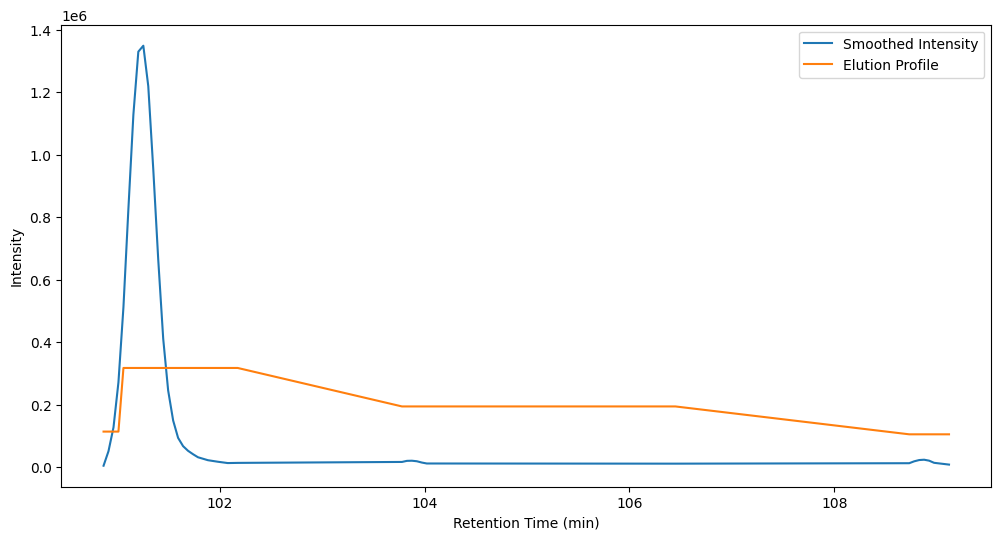

In [801]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(merged["rt"], merged["smoothed_intensity"], label="Smoothed Intensity")
ax.plot(merged["rt"], merged["intensity"], label="Elution Profile")
ax.set_xlabel("Retention Time (min)")
ax.set_ylabel("Intensity")
ax.legend()
plt.show()

# 2. Ions co-elution (MS1 level)

## 2.1 Pearson correlations of the smoothed elution profile of the “best” fragment with the MS1 elution profiles extracted using the base mass accuracy as well as 0.45 and 0.2 of the base mass accuracy

### TO DISCUSS: difference with previous? unfragmented precursor m/z and MS1 profile?

In [802]:
def corr_precursor_best_fragment_ms1_acc(
    precursor, precursor_fragments, ms1_dict, ms1_acc_factors=[1.0, 0.45, 0.2]
):
    # Calculate the correlation for each MS1 accuracy factor
    corr_results = np.array([])
    for acc in ms1_acc_factors:
        corr, _ = corr_precursor_best_fragment(
            precursor, precursor_fragments, ms1_dict, acc
        )
        corr_results = np.append(corr_results, corr)
    return corr_results, elution_profile

In [803]:
corr_results, elution_profile = corr_precursor_best_fragment_ms1_acc(
    precursor, precursor_fragments, ms1_dict
)

corr_results

array([0.4736208 , 0.40233562, 0.36550375])

# 3. Isotopologue ions co-elution 

## 3.1 Pearson correlations of the smoothed elution profile of the “best” fragment with the MS1 elution profiles corresponding to the peptide featuring 1, 2 or 3 C13

In [ ]:
def corr_best_fragment_c13_isotopes(
    precursor,
    precursor_fragments,
    ms1_dict,
    c13_list=[1, 2, 3],
    isotope_mass=1.00335,
    acc_factor=1.0,
    use_all_rt=False,
    rt_tolerance=5.0,
):
    """
    Calculate Pearson correlations between the smoothed elution profile of the "best"
    fragment and MS1 elution profiles corresponding to the peptide featuring 1, 2, or 3 C13.

    Parameters
    ----------
    precursor : pd.DataFrame
        Precursor information containing calcmass and charge
    precursor_fragments : pd.DataFrame
        Fragment data for correlation calculation
    ms1_dict : dict
        MS1 data dictionary
    c13_list : list, default=[1, 2, 3]
        List of C13 isotope numbers to consider
    isotope_mass : float, default=1.00335
        Mass difference for C13 isotope
    acc_factor : float, default=1.0
        Accuracy factor for mass tolerance
    use_all_rt : bool, default=False
        Whether to use all RT points or only overlapping ones

    Returns
    -------
    correlations : np.ndarray
        Array of correlations for each C13 isotope
    """
    # Get the smoothed elution profile of the "best" fragment
    _, best_trace, smoothed_best_trace, _ = pearson_corr_top_n(
        precursor_fragments, use_all_rt=use_all_rt
    )

    if best_trace is None or len(best_trace) == 0:
        return np.full(len(c13_list), np.nan)

    # Create DataFrame with smoothed best trace
    smoothed_best_df = pd.DataFrame(
        {"rt": best_trace.index, "smoothed_intensity": smoothed_best_trace}
    )

    # Calculate base precursor m/z
    base_precursor_mz = precursor["calcmass"].iloc[0] / precursor["charge"].iloc[0]

    correlations = []

    for c13_count in c13_list:
        # Calculate m/z for the C13 isotope
        isotope_mz = base_precursor_mz + (
            c13_count * isotope_mass / precursor["charge"].iloc[0]
        )

        # Build elution profile for this isotope
        isotope_elution_profile = build_elution_profile(
            isotope_mz, ms1_dict, acc_factor=acc_factor
        )

        if not isotope_elution_profile:
            correlations.append(np.nan)
            continue

        # Convert to DataFrame
        isotope_df = pd.DataFrame(
            list(isotope_elution_profile.items()), columns=["rt", "isotope_intensity"]
        )

        # Merge with smoothed best trace using nearest RT matching
        merged = pd.merge_asof(
            smoothed_best_df.sort_values("rt"),
            isotope_df.sort_values("rt"),
            on="rt",
            direction="nearest",
            tolerance=rt_tolerance,
        )

        # Remove rows where either intensity is NaN
        merged_clean = merged.dropna(subset=["smoothed_intensity", "isotope_intensity"])

        if len(merged_clean) < 2:
            correlations.append(np.nan)
            continue

        # Calculate Pearson correlation
        corr = merged_clean["smoothed_intensity"].corr(
            merged_clean["isotope_intensity"]
        )
        correlations.append(corr if not pd.isna(corr) else 0.0)

    return np.array(correlations)

In [844]:
# Test the C13 isotope correlation function
c13_correlations = corr_best_fragment_c13_isotopes(
    precursor, precursor_fragments, ms1_dict
)
c13_correlations

array([0.1810811 , 0.98980408, 0.99502015])

## 3.2 Sum of Pearson correlations of elution profiles corresponding to the top 6 fragments featuring one C13 with the smoothed elution profile of the “best” fragment

In [ ]:
def isotope_pearson_frag(
    precursor_fragments, precursor, isotope_mass=1.00335, c13_list=[1]
):  # TODO: how to configure c13_list from config
    # Create an array to hold the correlations
    correlations = np.array([])

    # Get smoothed best_fragment trace
    _, best_trace, smoothed_best_trace, _ = pearson_corr_top_n(
        precursor_fragments, n=12
    )
    smoothed_best_df = pd.DataFrame(
        {"rt": best_trace.index, "smoothed_intensity": smoothed_best_trace}
    )

    for c13 in c13_list:
        isotope_error = c13 * isotope_mass
        # Filter the psms identified at the given isotope error
        precursor_filtered = precursor[precursor["isotope_error"] == isotope_error][
            "psm_id"
        ].values

        precursor_fragments_filtered = precursor_fragments[
            precursor_fragments["psm_id"].isin(precursor_filtered)
        ]

        # Calculate correlation between smoothed_best_df and precursor_fragments_filtered
        merged = smoothed_best_df.merge(
            precursor_fragments_filtered[["rt", "fragment_intensity"]],
            on="rt",
            suffixes=("", "_frag"),
        )
        corr = merged["smoothed_intensity"].corr(merged["fragment_intensity"])
        correlations = np.append(correlations, corr)

    return correlations

In [836]:
correlations = isotope_pearson_frag(precursor_fragments, precursor)

In [837]:
correlations

array([0.4076935])

## 3.3 Pearson correlations of elution profiles corresponding to the top 6 fragments, from masses of which (C13 - C12) mass was subtracted, with the smoothed elution profile of the “best” fragment

In [ ]:
def corr_top6_fragments_c13_subtracted(
    precursor_fragments, ms2dict, isotope_mass=1.00335, top_n=6, use_all_rt=False
):
    """
    Calculate Pearson correlations between elution profiles of the top 6 fragments
    (with C13 mass subtracted from their masses) and the smoothed elution profile
    of the "best" fragment.

    This feature looks for fragment elution profiles where the fragment masses
    have been shifted down by the C13 isotope mass difference.

    Parameters
    ----------
    precursor_fragments : pd.DataFrame
        Fragment data containing fragment information
    ms2dict : dict
        MS2 spectral data dictionary
    isotope_mass : float, default=1.00335
        Mass difference for C13 isotope (C13 - C12)
    top_n : int, default=6
        Number of top fragments to consider
    use_all_rt : bool, default=False
        Whether to use all RT points or only overlapping ones

    Returns
    -------
    correlations : np.ndarray
        Array of correlations for top 6 fragments with C13 mass subtracted
    """
    # Get the smoothed elution profile of the "best" fragment
    _, best_trace, smoothed_best_trace, _ = pearson_corr_top_n(
        precursor_fragments, use_all_rt=use_all_rt
    )

    if best_trace is None or len(best_trace) == 0:
        return np.full(top_n, np.nan)

    # Create DataFrame with smoothed best trace
    smoothed_best_df = pd.DataFrame(
        {"rt": best_trace.index, "smoothed_intensity": smoothed_best_trace}
    )

    # Get top n fragments by intensity
    top_fragments = find_top_n_fragments(precursor_fragments, top_n)

    correlations = []

    for frag_name in top_fragments:
        # Get fragment data for this specific fragment
        frag_data = precursor_fragments[
            precursor_fragments["fragment_names"] == frag_name
        ]

        if frag_data.empty:
            correlations.append(np.nan)
            continue

        # Calculate the target m/z with C13 mass subtracted
        original_mz = frag_data["fragment_mz_calculated"].iloc[0]
        charge = frag_data["fragment_charge"].iloc[0]
        c13_subtracted_mz = original_mz - (isotope_mass / charge)

        # Extract elution profile for the C13-subtracted m/z from MS2 data
        c13_subtracted_profile = {}

        # Go through each RT point where this fragment was observed
        for _, row in frag_data.iterrows():
            rt = row["rt"]
            scan = row["scannr"]

            # Look up the scan in ms2dict
            scan_data = ms2dict.get(scan, {})
            mzs = scan_data.get("mz", [])
            intensities = scan_data.get("intensity", [])

            # Handle numpy arrays properly
            if len(mzs) == 0 or len(intensities) == 0:
                continue

            # Find the closest m/z to our C13-subtracted target
            best_idx, best_val = search_sorted_tolerance_np(
                mzs, c13_subtracted_mz, tol=13  # Use default fragment mass tolerance
            )

            if best_idx is not None:
                c13_subtracted_profile[rt] = intensities[best_idx]

        if not c13_subtracted_profile:
            correlations.append(np.nan)
            continue

        # Convert to DataFrame for correlation calculation
        c13_df = pd.DataFrame(
            list(c13_subtracted_profile.items()),
            columns=["rt", "c13_subtracted_intensity"],
        )

        # Merge with smoothed best trace using nearest RT matching
        merged = pd.merge_asof(
            smoothed_best_df.sort_values("rt"),
            c13_df.sort_values("rt"),
            on="rt",
            direction="nearest",
            tolerance=5,  # RT tolerance
        )

        # Remove rows where either intensity is NaN
        merged_clean = merged.dropna(
            subset=["smoothed_intensity", "c13_subtracted_intensity"]
        )

        if len(merged_clean) < 2:
            correlations.append(np.nan)
            continue

        # Calculate Pearson correlation
        corr = merged_clean["smoothed_intensity"].corr(
            merged_clean["c13_subtracted_intensity"]
        )
        correlations.append(corr if not pd.isna(corr) else 0.0)

    # Pad with NaN if we have fewer fragments than requested
    while len(correlations) < top_n:
        correlations.append(np.nan)

    return np.array(correlations[:top_n])

In [850]:
# Test the C13 mass subtracted correlation function
c13_subtracted_correlations = corr_top6_fragments_c13_subtracted(
    precursor_fragments, ms2dict
)

c13_subtracted_correlations

array([0.98213745, 0.9864283 , 0.48697211, 0.9672019 , 0.99713056,
       0.99737305])

## 3.4 Sum of these correlations 

In [851]:
def sum_corr_top6_fragments_c13_subtracted(correlations):
    """
    Sum the Pearson correlations for the top 6 fragments with C13 mass subtracted.

    Parameters
    ----------
    correlations : np.ndarray
        Array of correlations for top 6 fragments

    Returns
    -------
    float
        Sum of correlations
    """
    return np.nansum(correlations)

In [852]:
sum_corr_top6_fragments_c13_subtracted(c13_subtracted_correlations)

np.float64(5.417243370576044)

# 4. Total signal

## 4.1 Natural logarithm of the sum of the areas below the elution curves of the top 6 fragments multiplied by the respective correlations with the smoothed elution profile of the "best" fragment

In [ ]:
def nl_AUC_top_n(precursor_fragments, n=6, use_all_rt=False):
    sorted_correlations, _, _, _ = pearson_corr_top_n(
        precursor_fragments, n=n, use_all_rt=use_all_rt
    )
    aucs = []
    for frag in find_top_n_fragments(precursor_fragments, n):
        frag_df = precursor_fragments[precursor_fragments["fragment_names"] == frag]
        frag_df_sorted = frag_df.sort_values("rt")
        rt = frag_df_sorted["rt"].to_numpy()
        intensity = frag_df_sorted["fragment_intensity"].to_numpy()
        auc = np.trapz(intensity, rt)
        aucs.append(auc)
    aucs = np.array(aucs)
    # Convert NaN to zero
    corrs = np.nan_to_num(sorted_correlations, nan=0.0)
    aucs = aucs[: len(corrs)]  # Align lengths
    weighted_aucs = aucs * corrs
    total_weighted_auc = np.sum(weighted_aucs)
    nl_total_weighted_auc = np.log(total_weighted_auc) if total_weighted_auc > 0 else 0
    return nl_total_weighted_auc

In [345]:
nl_total_weighted_auc = nl_AUC_top_n(precursor_fragments, n=6)

In [346]:
nl_total_weighted_auc

np.float64(15.595366663667184)

# 5. Measured relative fragment intensities

## 5.1 Cosine similarity measure (itself and to power 3) between the predicted and measured intensities of the top 6 fragments weighted by the squared values of the smoothed “best” fragment elution curve at the respective time points

In [352]:
precursor_preds = ms2pip_preds["GYINSLGALTGGQALQQAK/2"]

In [ ]:
def cos_pred_obs_weighted(
    precursor_fragments, precursor_preds, top_n=6, use_all_rt=False
):
    """
    Weighted cosine similarity between predicted and observed fragment intensities,
    averaged over RT with weights equal to b(t)^2 where b(t) is the smoothed
    elution profile of the 'best' fragment.

    Parameters
    ----------
    precursor_fragments : DataFrame
        Must contain columns:
        ['fragment_type','fragment_ordinals','fragment_charge','fragment_intensity',
         'rt','scannr','fragment_names', ...]
        Each row corresponds to one fragment at one time point (scan/RT).
    precursor_preds : dict
        Mapping like {"b1/1": float, "y7/2": float, ...} with predicted (relative) intensities.
    top_n : int
        Number of top fragments to use (default 6).

    Returns
    -------
    S : float
        Weighted cosine similarity in [0, 1].
    S_cubed : float
        Cubic variant S**3.
    cosine_by_scan : np.ndarray, shape (T,)
        Per-scan cosine similarity values before weighting.
    top_fragments : list of str
        Fragment name keys used (length <= top_n).
    scan_index : np.ndarray, shape (T,)
        Scan indices (or RTs) corresponding to cosine_by_scan and weights.
    """
    # --- 1) Select top-N fragment names using your helper (by area or max-intensity as implemented there)
    used_fragments = find_top_n_fragments(precursor_fragments, top_n=top_n)

    # --- obtain best trace (Series indexed by rt) and smoothed trace (ndarray) ---
    _, best_trace, smoothed_best_trace, _ = pearson_corr_top_n(
        precursor_fragments, n=max(top_n, 12), use_all_rt=use_all_rt
    )

    if best_trace is None or len(best_trace) == 0:
        return 0.0, 0.0, np.array([]), [], np.array([])

    # Align everything to the RT grid of the best fragment
    rt_index = best_trace.index.to_numpy()
    b = np.asarray(smoothed_best_trace, dtype=np.float64)
    if b.shape[0] != rt_index.shape[0]:
        raise ValueError("Best trace and RT index length mismatch.")

    # --- pivot to (rt × fragment) and align to best_trace.index ---
    piv = (
        precursor_fragments.pivot_table(
            index="rt",
            columns="fragment_names",
            values="fragment_intensity",
            aggfunc="sum",
        )
        .reindex(rt_index)
        .fillna(0.0)
    )

    # restrict to the chosen fragments, in that order
    piv = piv.reindex(columns=used_fragments).fillna(0.0)

    # measured matrix (K x T)
    measured = piv.to_numpy(dtype=np.float64).T  # shape (K, T)
    K, T = measured.shape
    if T == 0 or K == 0:
        return 0.0, 0.0, np.zeros(0), used_fragments, rt_index

    # --- build predicted vector for the same K fragments ---
    # # helper to construct keys like "b3/1"
    # def frag_key(df_rows: pd.DataFrame) -> str:
    #     r = df_rows.iloc[0]
    #     return f"{r['fragment_type']}{int(r['fragment_ordinals'])}/{int(r['fragment_charge'])}"

    predicted_vals: List[float] = []
    # we need any row of each fragment to read its type/ordinal/charge
    meta = (
        precursor_fragments[precursor_fragments["fragment_names"].isin(used_fragments)]
        .sort_values("rt")
        .drop_duplicates(subset=["fragment_names"], keep="first")
        .set_index("fragment_names")
    )

    for frag_name in used_fragments:
        if frag_name in meta.index:
            key = f"{meta.loc[frag_name, 'fragment_type']}{int(meta.loc[frag_name, 'fragment_ordinals'])}/{int(meta.loc[frag_name, 'fragment_charge'])}"
            predicted_vals.append(float(precursor_preds.get(key, 0.0)))
        else:
            predicted_vals.append(0.0)

    predicted = np.asarray(predicted_vals, dtype=np.float64)  # shape (K,)

    # guard against all-zero predictions (or degenerate observations)
    pred_norm = float(np.linalg.norm(predicted))
    if pred_norm == 0.0:
        return 0.0, 0.0, np.zeros(T), used_fragments, rt_index

    # --- cosine per rt ---
    cosine_by_rt = np.zeros(T, dtype=np.float64)
    for j in range(T):
        obs = measured[:, j]
        obs_norm = float(np.linalg.norm(obs))
        if obs_norm == 0.0:
            cosine_by_rt[j] = 0.0
        else:
            cosine_by_rt[j] = float(np.dot(obs, predicted) / (obs_norm * pred_norm))

    # numerical safety
    np.clip(cosine_by_rt, 0.0, 1.0, out=cosine_by_rt)

    # --- weighted average with b(t)^2 ---
    w = b**2
    w_sum = float(w.sum())
    if w_sum == 0.0:
        return 0.0, 0.0, np.zeros(T), used_fragments, rt_index

    S = float(np.sum(w * cosine_by_rt) / w_sum)
    S_cubed = S**3

    results = np.array([S, S_cubed])

    return results

In [411]:
cos_pred_obs_weighted(precursor_fragments, precursor_preds)

array([0.99517575, 0.98559697])

# 5.2 Relative intensities of the top 6 fragments (6 scores)

In [420]:
def rel_int_top_6(precursor_fragments):
    top_6 = find_top_n_fragments(precursor_fragments, top_n=6)
    top_6_int = [
        precursor_fragments[precursor_fragments["fragment_names"] == frag][
            "fragment_intensity"
        ].max()
        for frag in top_6
    ]
    rel_top_6_int = (
        top_6_int / np.max(top_6_int) if np.max(top_6_int) > 0 else top_6_int
    )
    return rel_top_6_int

In [421]:
top_6 = rel_int_top_6(precursor_fragments)
top_6

array([1.        , 0.62490544, 0.45100085, 0.44059697, 0.22379807,
       0.22329567])

# 6. Mass Accuracy

## 6.1 Measured mass accuracy of the top 6 fragments at the elution apex weighted by the Pearson correlations of the respective elution curves with the smoothed elution curve of the “best” fragment (6 scores)


In [ ]:
def mass_acc_weighted(precursor_fragments, use_all_rt=False):
    apex_rt = precursor_fragments["rt"].iloc[
        precursor_fragments["fragment_intensity"].idxmax()
    ]
    fragments_at_apex = precursor_fragments[precursor_fragments["rt"] == apex_rt]
    top_6_apex = fragments_at_apex.nlargest(6, "fragment_intensity")
    # Filter out any fragments that are not in the top 6
    filtered_fragments = precursor_fragments[
        precursor_fragments["fragment_names"].isin(top_6_apex["fragment_names"])
    ]
    # Calculate the pearson corr of these fragments with the "best" fragment
    _, _, _, correlations = pearson_corr_top_n(
        precursor_fragments, n=6, use_all_rt=use_all_rt
    )

    filtered_correlations = [
        corr
        for (frag, corr) in correlations.items()
        if frag in filtered_fragments["fragment_names"].values
    ]

    mass_accs = top_6_apex["ppm_error"].to_numpy()
    weighted_mass_accs = mass_accs * filtered_correlations

    return weighted_mass_accs

In [458]:
weighted_mass_accs = mass_acc_weighted(precursor_fragments)
weighted_mass_accs

array([0.72168677, 0.48738242, 0.92806253, 0.8049175 , 0.07313659,
       0.75679727])

# 7. Retention time

## 7.1 Retention time apex

In [459]:
def RT_apex(precursor_fragments):
    idx = precursor_fragments["fragment_intensity"].idxmax()
    apex_rt = precursor_fragments.loc[idx, "rt"]

    return apex_rt

In [460]:
RT_apex(precursor_fragments)

np.float64(101.25427)

## 7.2 Square root of the absolute difference between measured and predicted retention times


In [470]:
def pred_obs_RT(precursor_fragments, deeplc_preds):
    apex_rt = RT_apex(precursor_fragments)
    precursor = precursor_fragments["peptide"].iloc[0]
    pred_rt = deeplc_preds[deeplc_preds["peptide"] == precursor]["rt_predictions"].iloc[
        0
    ]

    sqrt_diff = np.sqrt(abs(apex_rt - pred_rt))
    return sqrt_diff

In [471]:
pred_obs_RT(precursor_fragments=precursor_fragments, deeplc_preds=deeplc_preds)

np.float64(1.6466044369778052)

# 8. Elution profile shape

## 8.1 The chromatogram scanning window is split into five segments and relative total intensities are calculated for the “best” fragment for these segments (5 scores)

In [480]:
def best_fr_scanning_split(precursor_fragments, splits=5):
    best_fragment = find_best_fragment(precursor_fragments)
    fragment_df = precursor_fragments[
        precursor_fragments["fragment_names"] == best_fragment
    ]
    rt_distribution_min = fragment_df["rt"].min()
    rt_distribution_max = fragment_df["rt"].max()
    rt_range = rt_distribution_max - rt_distribution_min

    rt_split = rt_range / splits

    split_intensities = []
    for i in range(splits):
        split_min = rt_distribution_min + i * rt_split
        split_max = rt_distribution_min + (i + 1) * rt_split
        split_intensities.append(
            fragment_df[
                (fragment_df["rt"] >= split_min) & (fragment_df["rt"] < split_max)
            ]["fragment_intensity"].sum()
        )

    # Normalize by total
    total_intensity = sum(split_intensities)
    if total_intensity > 0:
        split_intensities = [x / total_intensity for x in split_intensities]
    return split_intensities

In [481]:
best_fr_scanning_split(precursor_fragments)

[np.float64(0.000269398041652294),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.9785524028765549),
 np.float64(0.021178199081792838)]

# 9. Presence of other putative elution peaks

## 9.1 Sum of the Pearson correlations between the elution profiles of the top 6 fragments and the smoothed elution profile of the “best” fragment, from which the maximum of such correlation sums for all putative elution peaks considered has been subtracted

### TO DISCUSS? DOABLE?

## 9.2 log(max(1.0, s) / (S + 1.0)), where s is the sum of the Pearson correlation between the elution profiles of the top 6 fragments and the smoothed elution profile of the “best” fragment, and S is the sum of such correlation sums for all putative elution peaks


### TO DISCUSS? DOABLE?

# 10. Library charcteristics of the precursors

## 10.1 Library intensities of the fragments 2 to 12 (fragments ordered by their reference library intensities) relative to the top fragment

In [494]:
def relative_pred_intensities_top(precursor_fragments, ms2pip_preds, top_n=12):
    precursor = precursor_fragments["peptide"].iloc[0]
    charge = precursor_fragments["charge"].iloc[0]
    proforma = precursor + "/" + str(charge)
    pred_ints = ms2pip_preds[proforma]

    # Order predicted intensities
    # Convert dict to pandas Series for sorting
    pred_ints = pd.Series(pred_ints)
    pred_ints = pred_ints.sort_values(ascending=False).head(top_n)

    # Normalize by top fragment intensity
    top_intensity = pred_ints.max()
    if top_intensity > 0:
        pred_ints = pred_ints / top_intensity
    # Remove first
    pred_ints = pred_ints.iloc[1:].to_numpy()
    return pred_ints

In [495]:
pred_ints = relative_pred_intensities_top(precursor_fragments, ms2pip_preds)

In [496]:
pred_ints

array([0.62446064, 0.5642461 , 0.53919506, 0.43795532, 0.32467735,
       0.25790223, 0.25758395, 0.23893973, 0.23744628, 0.21010783,
       0.20528834], dtype=float32)

## 10.2 Precursor m/z

In [499]:
precursor_mz = precursor["calcmass"].iloc[0] / precursor["charge"].iloc[0]
precursor_mz

np.float64(944.50035)

## 10.3 Precursor charge

In [501]:
precursor_charge = precursor["charge"].iloc[0]
precursor_charge

np.int64(2)

## 10.4 Precursor length

In [504]:
precursor_length = len(precursor["stripped_peptide"].iloc[0])
precursor_length

19

## 10.5 Number of library fragments

In [514]:
def n_lib_fragments(ms2pip_preds, precursor):
    peptide = precursor["peptide"].iloc[0]
    charge = precursor["charge"].iloc[0]
    proforma = peptide + "/" + str(charge)

    pred_ints = ms2pip_preds[proforma]

    # Keep only entries with intensity > 0.
    pred_ints = {k: v for k, v in pred_ints.items() if v > 0}
    n_lib_fragments = len(pred_ints)
    return n_lib_fragments

In [515]:
n_lib_fragment = n_lib_fragments(ms2pip_preds, precursor)
n_lib_fragment

36